# ECMWF-style 2 m temperature animation

This uses cleopatra's `temperature_2m` data-style — **ECMWF's actual default** (from earthkit-plots'
`2t.yml`): the muted **`Spectral_r`** colour ramp rendered as **discrete 2 °C contour bands** over −40…40 °C with
the out-of-range ends capped (`extend="both"`) — the look of a professional weather-service chart, not the neon
blue→magenta rainbow. (The generic `temperature` preset auto-ranges to the data instead; pass it `vmin`/`vmax`
to pin a non-Celsius field to a chosen range.)

The map is composed like an ECMWF chart: temperature bands + grey coastlines/borders + an arrow-capped colorbar
labelled with the contour levels, over the real ERA5-Land data (1 Jun – 15 Jul 2026).

In [1]:
import matplotlib

matplotlib.use("Agg")

from pathlib import Path

import numpy as np

from cleopatra.animation import embed_gif
from cleopatra.array_glyph import ArrayGlyph

# --- data: an ERA5-Land 2 m-temperature stack over Europe (°C, 23 daily frames) ---
npz = np.load(Path("../../../examples/data/europe_t2m.npz"), allow_pickle=True)
celsius = npz["celsius"][::2]  # every other day
labels = list(npz["labels"])[::2]
west, south, east, north = (float(v) for v in npz["extent"])
extent = [west, east, south, north]  # ArrayGlyph extent order: [xmin, xmax, ymin, ymax]

print("stack:", celsius.shape, "| frames:", labels[0], "->", labels[-1])

stack: (23, 111, 164) | frames: Jun 01 -> Jul 15


## The animation

Everything below comes from **one** thing: `style="temperature_2m"`. `ArrayGlyph` reads the preset for the
`Spectral_r` ramp, the 2 °C contour bands, `extend="both"`, and the arrow-capped colorbar, and `.animate()`
runs the per-frame loop for us — no manual `ScalarMappable`, `BoundaryNorm`, `imshow`, or `FuncAnimation`. The
`basemap` callable draws the static coastlines/borders with the glyph's own `add_features` on top of every frame.

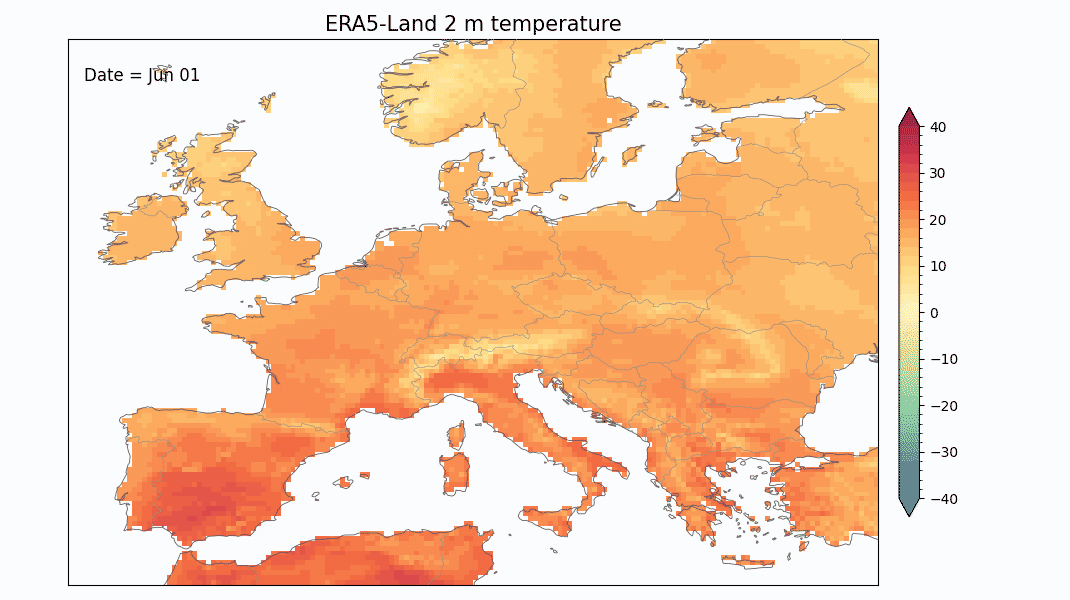

In [2]:
def add_reference(glyph):
    """Draw grey coastlines + borders on top of every frame (a `basemap` callable).

    Uses the glyph's own `add_features` (a `GeoMixin` method that draws Natural
    Earth layers on `glyph.ax` with the glyph's CRS) -- no standalone helpers.
    """
    glyph.add_features("coastline", "50m", color="0.35", linewidth=0.6, zorder=5)
    glyph.add_features("borders", "50m", color="0.55", linewidth=0.4, zorder=5)


# The preset carries the cmap + 2 °C levels + extend + colorbar; ArrayGlyph applies
# them, and `animate` iterates the stack. `colorbar=True` draws the real ECMWF
# colorbar (the preset's swatch is replaced by a full arrow-capped bar).
glyph = ArrayGlyph(celsius, extent=extent, style="temperature_2m")
anim = glyph.animate(
    time=labels,
    colorbar=True,
    basemap=add_reference,
    title="ERA5-Land 2 m temperature",
)
embed_gif(anim, fps=6)

That whole ECMWF chart — banded `Spectral_r`, the 2 °C `levels`, `extend="both"`, the arrow-capped
colorbar, coastlines — is one `ArrayGlyph(..., style="temperature_2m")` plus `.animate(...)`, because the look is
baked into the preset. The same one line styles a static `.plot()` too. For a field that is *not* fixed to the ECMWF
−40 … 40 °C window, use the generic `temperature` style (optionally with `vmin`/`vmax`), which
auto-ranges to the data.